# MLP Deep-Dive: Tuning a Neural Net for ZTF SNIa Hubble Residuals

## Motivation

The `ZTF_ML_variety_sampler.ipynb` notebook tested 8 different regressors and found that a
Multi-Layer Perceptron (MLP) is competitive with tree-based methods — but it only tuned **one**
hyperparameter (`alpha`, L2 regularisation). This notebook gives the MLP a proper treatment:
every meaningful knob gets swept, justified, and the best configuration is identified.

## Dataset at a glance

| Property | Value |
|---|---|
| Samples (after quality cuts) | ~460–580 SNe Ia |
| Features | 9 host-galaxy + SN SALT2 properties |
| Target | `residual_centered` — Hubble residual $\Delta\mu$ |
| Train / Test split | 80 / 20 (random_state=42) |

## Why MLP tuning is non-trivial for this dataset

MLPs have a large hyperparameter space and interact badly with small datasets:

- **Small N (~460 training samples)** → overfitting is the primary failure mode
- **Low-dimensional input (9 features)** → huge networks are wasteful, not helpful
- **Noisy target** (Hubble residuals carry measurement scatter ~0.15 mag) →
  the network must *not* try to fit the noise
- **No GPU** → solver choice affects wall-clock time non-trivially

## Tuning roadmap (5 phases)

| Phase | Parameter(s) | What it controls |
|---|---|---|
| 1 | `hidden_layer_sizes` | Model capacity — depth and width |
| 2 | `activation` | Nonlinearity — expressiveness vs gradient flow |
| 3 | `solver` + `learning_rate_init` | Optimisation dynamics |
| 4 | `alpha` | L2 weight-decay regularisation |
| 5 | `early_stopping` + `validation_fraction` | Implicit regularisation via early exit |

Each phase locks in the best value from the previous phase before sweeping the next.
The final cell combines everything into a `RandomizedSearchCV` to check for synergies.

**Metric**: CV NMAD = $1.4826 \times \text{median}|\hat{y} - y|$ (robust to outliers, standard in SN cosmology)
alongside outlier fraction (fraction of SNe with $|\hat{y} - y| > 0.1$ mag).

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.stats import sigma_clip

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    learning_curve,
    RandomizedSearchCV,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPRegressor
from scipy.stats import loguniform, uniform

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('Libraries loaded.')

Libraries loaded.


---
## Data Loading & Quality Cuts

Identical pipeline to `ZTF_ML_variety_sampler.ipynb` — keeping this self-contained.

In [35]:
df = pd.read_csv('ZTF_DESI_ml_work/ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv')
print(len(df), 'SNe before quality cuts.')

# Paper quality flags
df = df[(df['lccoverage_flag'] == 1) & (df['fitquality_flag'] == 1)]
print(len(df), 'SNe after lccoverage + fitquality flags.')

# Derived feature
df['SDSS_g_minus_r'] = df['ABSMAG01_SDSS_G'] - df['ABSMAG01_SDSS_R']

# 3-sigma clip on Hubble residuals
resid_before = df['residual_centered'].copy()
clip = sigma_clip(df['residual_centered'], sigma=3, maxiters=1)
df = df.loc[~clip.mask].reset_index(drop=True)
print(len(df), 'SNe after 3-sigma clip.')

# Physical host-galaxy cuts
df = df.loc[df['SFR'] <= 2.5].reset_index(drop=True)
df = df.loc[df['DN4000'] >= 0.5].reset_index(drop=True)
df = df.loc[df['AGE'] >= 2].reset_index(drop=True)
print(len(df), 'SNe after physical host-galaxy cuts.')

yerr_all = df['sigma_mu_meas'].copy()
print('\nFinal sample:', len(df), 'SNe')

776 SNe before quality cuts.
579 SNe after lccoverage + fitquality flags.
563 SNe after 3-sigma clip.
550 SNe after physical host-galaxy cuts.

Final sample: 550 SNe


In [36]:
feature_cols = [
    'LOGMSTAR', 'c', 'x1', 'SFR', 'VDISP',
    'DN4000', 'SDSS_g_minus_r', 'AGE', 'redshift',
]
target_col = 'residual_centered'

X = df[feature_cols].copy()
y = df[target_col].copy()

Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=SEED
)

print(f'Training : {len(Xtr)} samples')
print(f'Test     : {len(Xte)} samples')

Training : 440 samples
Test     : 110 samples


---
## Helper Functions

In [37]:
def nmad(y_true, y_pred):
    """Normalised median absolute deviation — standard SN cosmology scatter metric."""
    return 1.4826 * float(np.median(np.abs(np.asarray(y_pred) - np.asarray(y_true))))


def outlier_rate(y_true, y_pred, threshold=0.1):
    """Fraction of predictions with |residual| > threshold mag."""
    return 100.0 * float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) > threshold))


def cv_scores(pipe, X, y, cv=5):
    """Return CV NMAD and outlier rate via cross_val_predict."""
    yp = cross_val_predict(pipe, X, y, cv=cv)
    return nmad(y, yp), outlier_rate(y, yp)


def make_mlp_pipe(**kwargs):
    """Convenience: StandardScaler → MLPRegressor with given kwargs."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(random_state=SEED, **kwargs)),
    ])


def dual_axis_sweep(x_vals, nmad_vals, outlier_vals, x_label, title,
                    best_x=None, log_x=False):
    """Reusable twin-axis plot for parameter sweeps."""
    fig, ax1 = plt.subplots(figsize=(9, 5))
    plot_fn = ax1.semilogx if log_x else ax1.plot
    plot_fn(x_vals, nmad_vals, 'o-', color='tab:blue', label='CV NMAD')
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('CV NMAD', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    if best_x is not None:
        ax1.axvline(best_x, color='tab:blue', linestyle='--', alpha=0.6,
                    label=f'Best = {best_x}')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    plot_fn2 = ax2.semilogx if log_x else ax2.plot
    plot_fn2(x_vals, outlier_vals, 's--', color='tab:red', label='Outlier Rate %')
    ax2.set_ylabel('Outlier Rate (%)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.legend(loc='upper right')

    plt.title(title)
    fig.tight_layout()
    plt.show()


print('Helpers defined.')

Helpers defined.


---
## Phase 1 — Architecture: `hidden_layer_sizes`

### Why this is the first thing to tune

The architecture determines the **capacity** of the network — how many parameters it can
learn and how complex a function it can represent. For all subsequent hyperparameter choices
to be meaningful, the architecture must be set to a reasonable size first.

### Design space

We sweep three orthogonal axes:

| Axis | Options | What we learn |
|---|---|---|
| **Width** | 8 → 256 neurons (single hidden layer) | How many neurons are needed per layer |
| **Depth** | 1 → 3 hidden layers (fixed width=64) | Whether stacking layers helps |
| **Hourglass vs uniform** | (64,32,16), (128,64,32) | Pyramid architectures |

### Prior expectation for this dataset

With 9 input features and ~460 training samples, a single hidden layer with ≤64 neurons
is likely optimal. Deeper networks add parameters without adding information when N is small.
The Universal Approximation Theorem guarantees that *one* hidden layer is sufficient for
any continuous function — depth buys efficiency, not expressiveness, for smooth targets.

  width=   8  NMAD=0.2375  Outlier%=66.1
  width=  16  NMAD=0.1949  Outlier%=59.3
  width=  32  NMAD=0.1890  Outlier%=59.1
  width=  48  NMAD=0.1741  Outlier%=57.5
  width=  64  NMAD=0.1757  Outlier%=58.4
  width=  96  NMAD=0.1729  Outlier%=55.0
  width= 128  NMAD=0.1685  Outlier%=55.0
  width= 192  NMAD=0.1571  Outlier%=52.7
  width= 256  NMAD=0.1644  Outlier%=53.9

Best single-layer width = 192


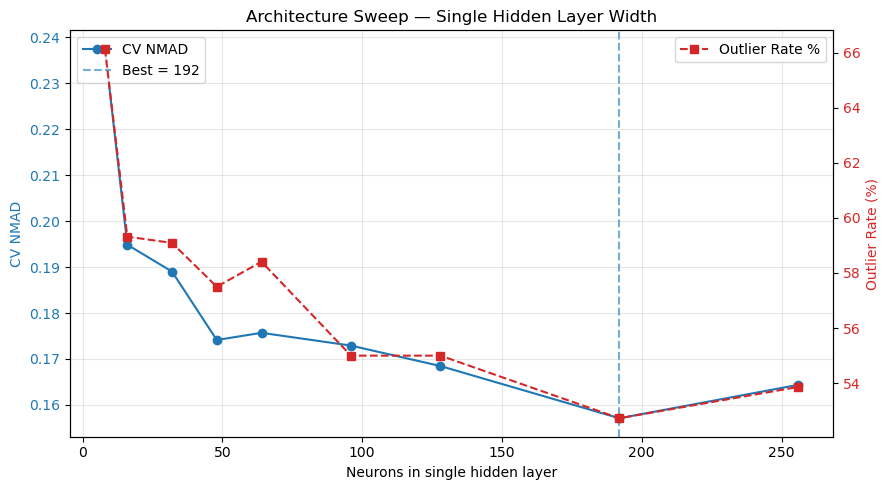

In [38]:
# ---- Width sweep (single hidden layer) ----
widths = [8, 16, 32, 48, 64, 96, 128, 192, 256]
nmad_w, outlier_w = [], []

for w in widths:
    pipe = make_mlp_pipe(
        hidden_layer_sizes=(w,), activation='relu',
        alpha=1e-3, learning_rate_init=1e-3, max_iter=1000, early_stopping=False,
    )
    n, o = cv_scores(pipe, Xtr, ytr)
    nmad_w.append(n)
    outlier_w.append(o)
    print(f'  width={w:4d}  NMAD={n:.4f}  Outlier%={o:.1f}')

best_width = widths[int(np.argmin(nmad_w))]
print(f'\nBest single-layer width = {best_width}')

dual_axis_sweep(
    widths, nmad_w, outlier_w,
    x_label='Neurons in single hidden layer',
    title='Architecture Sweep — Single Hidden Layer Width',
    best_x=best_width, log_x=False,
)

  (64,)                 NMAD=0.1757  Outlier%=58.4
  (64, 64)              NMAD=0.1699  Outlier%=56.8
  (64, 64, 64)          NMAD=0.1809  Outlier%=57.0
  (64, 32)              NMAD=0.1668  Outlier%=55.5
  (64, 32, 16)          NMAD=0.1705  Outlier%=56.1
  (128, 64)             NMAD=0.1607  Outlier%=53.4
  (128, 64, 32)         NMAD=0.1749  Outlier%=55.9
  (32, 16)              NMAD=0.1612  Outlier%=53.4
  (32,)                 NMAD=0.1890  Outlier%=59.1
  (16,)                 NMAD=0.1949  Outlier%=59.3

Best architecture = (128, 64) → (128, 64)


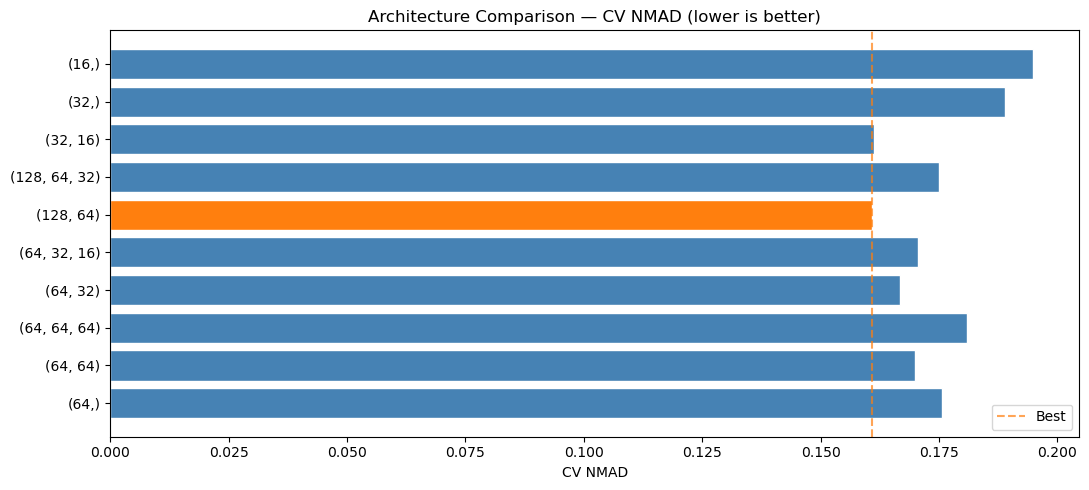

In [39]:
# ---- Depth sweep (fixed width=64) ----
architectures = {
    '(64,)'          : (64,),
    '(64, 64)'       : (64, 64),
    '(64, 64, 64)'   : (64, 64, 64),
    '(64, 32)'       : (64, 32),
    '(64, 32, 16)'   : (64, 32, 16),
    '(128, 64)'      : (128, 64),
    '(128, 64, 32)'  : (128, 64, 32),
    '(32, 16)'       : (32, 16),
    '(32,)'          : (32,),
    '(16,)'          : (16,),
}

arch_results = {}

for label, arch in architectures.items():
    pipe = make_mlp_pipe(
        hidden_layer_sizes=arch, activation='relu',
        alpha=1e-3, learning_rate_init=1e-3, max_iter=1000, early_stopping=False,
    )
    n, o = cv_scores(pipe, Xtr, ytr)
    arch_results[label] = {'nmad': n, 'outlier': o, 'arch': arch}
    print(f'  {label:20s}  NMAD={n:.4f}  Outlier%={o:.1f}')

best_arch_label = min(arch_results, key=lambda k: arch_results[k]['nmad'])
best_arch       = arch_results[best_arch_label]['arch']
print(f'\nBest architecture = {best_arch_label} → {best_arch}')

# Bar chart
labels = list(arch_results.keys())
nmad_vals   = [arch_results[k]['nmad']    for k in labels]
colors = ['tab:orange' if k == best_arch_label else 'steelblue' for k in labels]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(labels, nmad_vals, color=colors, edgecolor='white')
ax.set_xlabel('CV NMAD')
ax.set_title('Architecture Comparison — CV NMAD (lower is better)')
ax.axvline(min(nmad_vals), color='tab:orange', linestyle='--', alpha=0.7, label='Best')
ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 2 — Activation Function: `activation`

### What the activation function does

The activation function $f$ is applied element-wise after each linear transformation:
$\mathbf{h}^{(l)} = f(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)})$.
Without it, the entire network collapses to a single linear transformation.

### Candidates and their physics-motivated tradeoffs

| Activation | Formula | Pros | Cons |
|---|---|---|---|
| `relu` | $\max(0, x)$ | No vanishing gradient, fast | Dead neurons if $x < 0$ always |
| `tanh` | $\tanh(x)$ | Smooth, centred at 0 | Saturates for large $|x|$, slow gradient |
| `logistic` | $\sigma(x)$ | Smooth, bounded | Saturates, gradient ≈ 0 at extremes |

### Why this matters for Hubble residuals

Hubble residuals $\Delta\mu$ are approximately **normally distributed** with mean 0. The
target function is smooth (no sharp discontinuities expected). `tanh` is zero-centred and
outputs in $(-1, 1)$, which matches the scale of our target well. `relu` can produce
sparse representations but may not benefit a smooth regression task. We let the data decide.

  activation=relu        NMAD=0.1607  Outlier%=53.4
  activation=tanh        NMAD=0.1586  Outlier%=52.7
  activation=logistic    NMAD=0.1557  Outlier%=52.5

Best activation = logistic


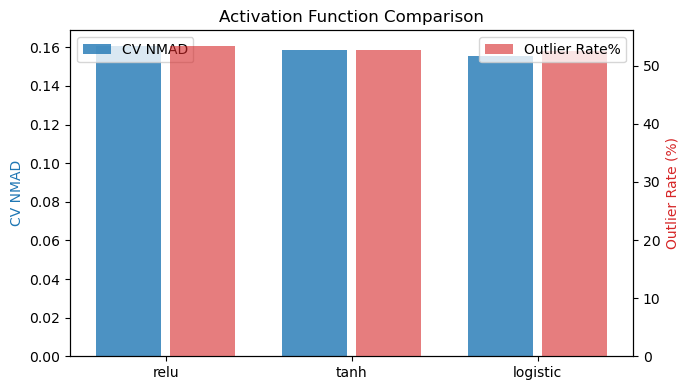

In [40]:
activations = ['relu', 'tanh', 'logistic']
act_results = {}

for act in activations:
    pipe = make_mlp_pipe(
        hidden_layer_sizes=best_arch, activation=act,
        alpha=1e-3, learning_rate_init=1e-3, max_iter=1000, early_stopping=False,
    )
    n, o = cv_scores(pipe, Xtr, ytr)
    act_results[act] = {'nmad': n, 'outlier': o}
    print(f'  activation={act:10s}  NMAD={n:.4f}  Outlier%={o:.1f}')

best_activation = min(act_results, key=lambda k: act_results[k]['nmad'])
print(f'\nBest activation = {best_activation}')

# Grouped bar chart
x = np.arange(len(activations))
fig, ax = plt.subplots(figsize=(7, 4))
nmad_a    = [act_results[a]['nmad']    for a in activations]
outlier_a = [act_results[a]['outlier'] for a in activations]
b1 = ax.bar(x - 0.2, nmad_a,    0.35, label='CV NMAD',       color='tab:blue',  alpha=0.8)
ax2b = ax.twinx()
b2 = ax2b.bar(x + 0.2, outlier_a, 0.35, label='Outlier Rate%', color='tab:red', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(activations)
ax.set_ylabel('CV NMAD', color='tab:blue')
ax2b.set_ylabel('Outlier Rate (%)', color='tab:red')
ax.set_title('Activation Function Comparison')
ax.legend(loc='upper left')
ax2b.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## Phase 3 — Solver & Learning Rate: `solver` + `learning_rate_init`

### Why optimisation dynamics matter

The solver is the gradient-based algorithm that minimises the training loss. Different
solvers make very different assumptions about the curvature of the loss landscape and
behave very differently on small vs large datasets.

### Solver comparison

| Solver | Type | Best for | Notes |
|---|---|---|---|
| `adam` | Stochastic first-order (adaptive moment) | Large datasets | Robust, widely used default |
| `lbfgs` | Quasi-Newton (full-batch second-order) | **Small datasets** | Much faster convergence for N<1000, no learning rate |
| `sgd` | Stochastic first-order with momentum | Very large data | Requires more hand-tuning, rarely best here |

**Key insight**: With only ~460 training samples, `lbfgs` has access to the exact gradient
at every iteration (no mini-batching). This means it can use curvature information that
`adam` approximates stochastically. `lbfgs` often converges in far fewer iterations and
frequently outperforms `adam` on small regression problems.

### Learning rate sweep (for `adam` only)

`lbfgs` does its own internal line search — it does not use `learning_rate_init`.
We sweep `learning_rate_init` only for `adam` and `sgd`.

In [41]:
# ---- Solver comparison (with default / sensible learning rates) ----
solver_configs = [
    ('lbfgs',  dict(solver='lbfgs', max_iter=2000)),
    ('adam',   dict(solver='adam',  max_iter=1000, learning_rate_init=1e-3, early_stopping=False)),
    ('sgd',    dict(solver='sgd',   max_iter=2000, learning_rate_init=1e-2, momentum=0.9,
                    learning_rate='adaptive', early_stopping=False)),
]

solver_results = {}
for name, kwargs in solver_configs:
    pipe = make_mlp_pipe(
        hidden_layer_sizes=best_arch, activation=best_activation,
        alpha=1e-3, **kwargs,
    )
    n, o = cv_scores(pipe, Xtr, ytr)
    solver_results[name] = {'nmad': n, 'outlier': o}
    print(f'  solver={name:6s}  NMAD={n:.4f}  Outlier%={o:.1f}')

best_solver = min(solver_results, key=lambda k: solver_results[k]['nmad'])
print(f'\nBest solver = {best_solver}')

  solver=lbfgs   NMAD=0.2753  Outlier%=70.7
  solver=adam    NMAD=0.1557  Outlier%=52.5
  solver=sgd     NMAD=0.1881  Outlier%=57.7

Best solver = adam


Best learning_rate_init (adam) = 0.01389  CV NMAD = 0.1519


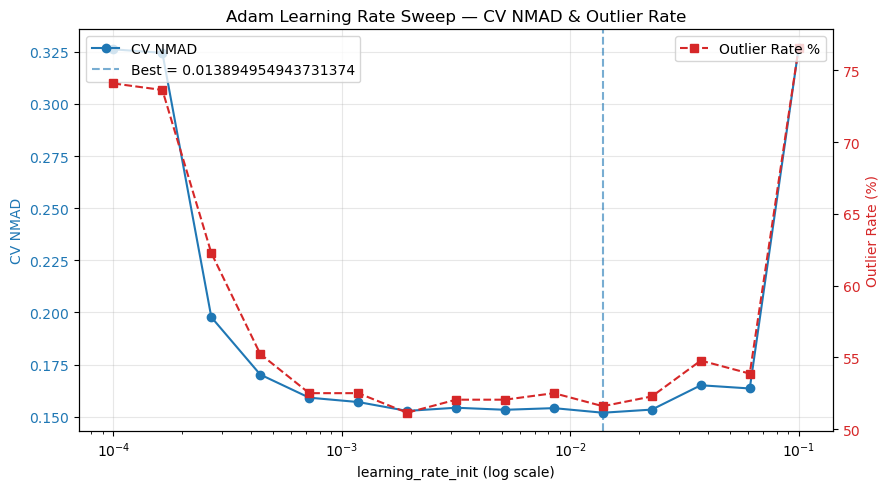

→ Using adam with lr = 0.01389


In [42]:
# ---- Learning rate sweep for adam ----
# (lbfgs does its own line search — skip this if lbfgs wins)
lr_range = np.logspace(-4, -1, 15)
nmad_lr, outlier_lr = [], []

for lr in lr_range:
    pipe = make_mlp_pipe(
        hidden_layer_sizes=best_arch, activation=best_activation,
        alpha=1e-3, solver='adam', learning_rate_init=lr,
        max_iter=1000, early_stopping=False,
    )
    n, o = cv_scores(pipe, Xtr, ytr)
    nmad_lr.append(n)
    outlier_lr.append(o)

best_lr_adam = float(lr_range[np.argmin(nmad_lr)])
print(f'Best learning_rate_init (adam) = {best_lr_adam:.4g}  CV NMAD = {min(nmad_lr):.4f}')

dual_axis_sweep(
    lr_range, nmad_lr, outlier_lr,
    x_label='learning_rate_init (log scale)',
    title='Adam Learning Rate Sweep — CV NMAD & Outlier Rate',
    best_x=best_lr_adam, log_x=True,
)

# Choose best solver: if lbfgs beat adam, use lbfgs (ignoring lr)
if best_solver == 'lbfgs':
    best_lr = None  # lbfgs doesn't use learning_rate_init
    print('→ Using lbfgs (no learning rate needed)')
else:
    best_lr = best_lr_adam
    print(f'→ Using {best_solver} with lr = {best_lr:.4g}')

---
## Phase 4 — L2 Regularisation: `alpha`

### What alpha controls

`alpha` is the coefficient of the **L2 weight-decay penalty** added to the loss:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MSE}} + \alpha \sum_{i,j} W_{ij}^2$$

This penalises large weight magnitudes, shrinking them toward zero and preventing
the network from memorising training noise.

### The tradeoff in this dataset

- **alpha too small** → weights grow unconstrained, network overfits the ~460 training SNe
- **alpha too large** → all weights pushed to ~0, network reduces to a constant predictor

The 15-point log-sweep covers six decades from $10^{-5}$ to $10^1$ to fully map the
regularisation landscape. We use the **architecture and solver already locked in from
Phases 1–3** so that alpha is tuned in its true operating context (not with a
mismatched architecture that would shift the optimal point).

### Note on `early_stopping=False`

Early stopping is a second form of regularisation. To cleanly isolate alpha's effect,
we disable it here. Phase 5 will assess whether early stopping adds further benefit
on top of the optimal alpha.

Best alpha = 0.06158  CV NMAD = 0.1502


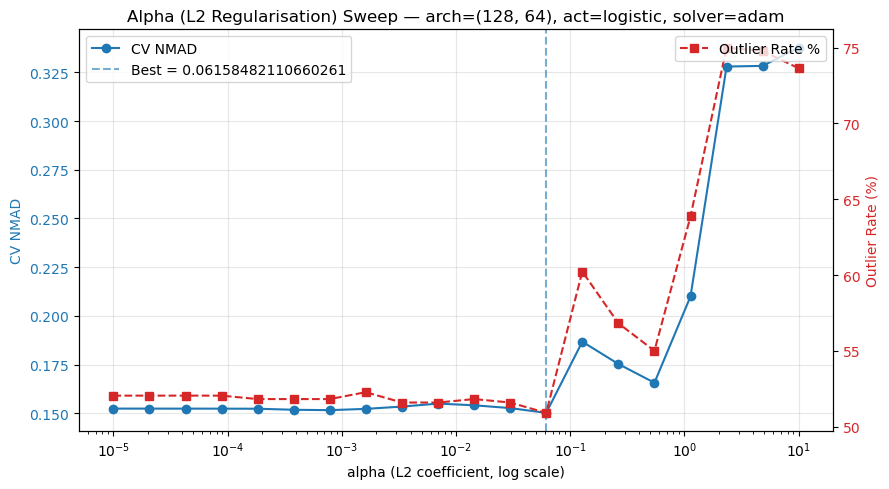

In [43]:
alpha_range = np.logspace(-5, 1, 20)
nmad_alpha, outlier_alpha = [], []

# Build solver kwargs from phase 3 results
if best_solver == 'lbfgs':
    solver_kwargs = dict(solver='lbfgs', max_iter=2000)
elif best_solver == 'sgd':
    solver_kwargs = dict(solver='sgd', max_iter=2000, learning_rate_init=best_lr,
                         momentum=0.9, learning_rate='adaptive', early_stopping=False)
else:
    solver_kwargs = dict(solver='adam', max_iter=1000, learning_rate_init=best_lr,
                         early_stopping=False)

for alpha in alpha_range:
    pipe = make_mlp_pipe(
        hidden_layer_sizes=best_arch, activation=best_activation,
        alpha=alpha, **solver_kwargs,
    )
    n, o = cv_scores(pipe, Xtr, ytr)
    nmad_alpha.append(n)
    outlier_alpha.append(o)

best_alpha = float(alpha_range[np.argmin(nmad_alpha)])
print(f'Best alpha = {best_alpha:.4g}  CV NMAD = {min(nmad_alpha):.4f}')

dual_axis_sweep(
    alpha_range, nmad_alpha, outlier_alpha,
    x_label='alpha (L2 coefficient, log scale)',
    title=f'Alpha (L2 Regularisation) Sweep — arch={best_arch}, act={best_activation}, solver={best_solver}',
    best_x=best_alpha, log_x=True,
)

---
## Phase 5 — Early Stopping: `early_stopping` + `validation_fraction`

### What early stopping does

Early stopping monitors a held-out **validation fraction** of the training data and
halts training when the validation loss stops improving for `n_iter_no_change` epochs.
This is **implicit regularisation** — the network stops before it has time to overfit.

### Interaction with cross-validation

When `early_stopping=True`, sklearn internally holds out `validation_fraction` of the
training fold *within each CV fold*. This means the effective training set shrinks further
inside each fold. With only ~460 samples and 5-fold CV, each training fold already has
only ~368 samples; a 10% validation split reduces that to ~331. For our dataset this is
a real cost, so we sweep `validation_fraction` to find the right balance.

### Strategy

1. Compare `early_stopping=False` vs `True` (with `validation_fraction=0.1`)
2. If early stopping helps, sweep `validation_fraction` ∈ [0.05, 0.30]
3. Also sweep `n_iter_no_change` ∈ {5, 10, 20, 50} — how patient should we be?

**Note**: `lbfgs` does not support `early_stopping`. If `lbfgs` won Phase 3,
we assess `adam` with early stopping as an alternative.

In [44]:
# ---- Basic comparison: early_stopping on vs off ----
# For lbfgs we test adam with early stopping as the comparison
es_solver_kwargs = dict(solver='adam', max_iter=2000)
if best_solver == 'adam' and best_lr is not None:
    es_solver_kwargs['learning_rate_init'] = best_lr
elif best_solver == 'sgd' and best_lr is not None:
    es_solver_kwargs = dict(solver='sgd', max_iter=2000, learning_rate_init=best_lr,
                            momentum=0.9, learning_rate='adaptive')
    
es_configs = [
    ('no early stopping', dict(early_stopping=False)),
    ('early_stopping=True (vf=0.10)', dict(early_stopping=True, validation_fraction=0.10, n_iter_no_change=10)),
    ('early_stopping=True (vf=0.15)', dict(early_stopping=True, validation_fraction=0.15, n_iter_no_change=10)),
    ('early_stopping=True (vf=0.20)', dict(early_stopping=True, validation_fraction=0.20, n_iter_no_change=10)),
]

es_results = {}
for label, es_kw in es_configs:
    pipe = make_mlp_pipe(
        hidden_layer_sizes=best_arch, activation=best_activation,
        alpha=best_alpha, **es_solver_kwargs, **es_kw,
    )
    n, o = cv_scores(pipe, Xtr, ytr)
    es_results[label] = {'nmad': n, 'outlier': o}
    print(f'  {label:45s}  NMAD={n:.4f}  Outlier%={o:.1f}')

best_es_label = min(es_results, key=lambda k: es_results[k]['nmad'])
print(f'\nBest early-stopping config: {best_es_label}')

  no early stopping                              NMAD=0.1502  Outlier%=50.9
  early_stopping=True (vf=0.10)                  NMAD=0.1602  Outlier%=53.0
  early_stopping=True (vf=0.15)                  NMAD=0.1588  Outlier%=52.5
  early_stopping=True (vf=0.20)                  NMAD=0.1523  Outlier%=50.9

Best early-stopping config: no early stopping


  patience=  5  NMAD=0.1627  Outlier%=53.9
  patience= 10  NMAD=0.1602  Outlier%=53.0
  patience= 20  NMAD=0.1604  Outlier%=53.0
  patience= 30  NMAD=0.1601  Outlier%=52.7
  patience= 50  NMAD=0.1586  Outlier%=52.3

Best patience (n_iter_no_change) = 50


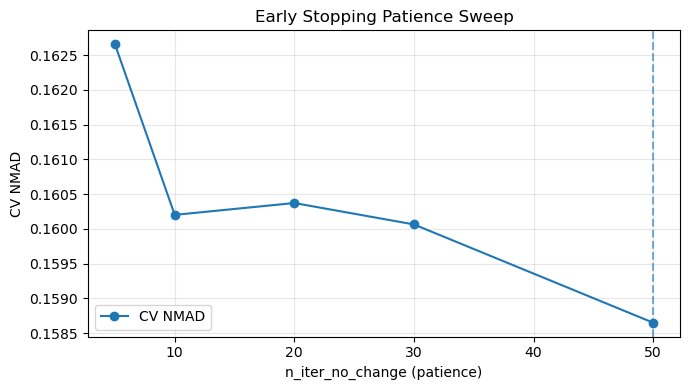

In [45]:
# ---- Patience sweep: n_iter_no_change ----
patience_vals = [5, 10, 20, 30, 50]
nmad_pat, outlier_pat = [], []

for patience in patience_vals:
    pipe = make_mlp_pipe(
        hidden_layer_sizes=best_arch, activation=best_activation,
        alpha=best_alpha, **es_solver_kwargs,
        early_stopping=True, validation_fraction=0.10,
        n_iter_no_change=patience,
    )
    n, o = cv_scores(pipe, Xtr, ytr)
    nmad_pat.append(n)
    outlier_pat.append(o)
    print(f'  patience={patience:3d}  NMAD={n:.4f}  Outlier%={o:.1f}')

best_patience = patience_vals[int(np.argmin(nmad_pat))]
print(f'\nBest patience (n_iter_no_change) = {best_patience}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(patience_vals, nmad_pat, 'o-', color='tab:blue', label='CV NMAD')
ax.axvline(best_patience, color='tab:blue', linestyle='--', alpha=0.6)
ax.set_xlabel('n_iter_no_change (patience)')
ax.set_ylabel('CV NMAD')
ax.set_title('Early Stopping Patience Sweep')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Phase 6 — Randomised Search: Joint Optimisation

### Why a joint search after phase-wise tuning?

The sequential phase-by-phase approach fixes each parameter greedily, which can miss
**interaction effects**: e.g., a wider architecture might need more regularisation, or
a different solver might prefer a different activation. A randomised search over the
joint space catches these synergies.

### Search space design

We concentrate the search around the phase-wise optima (±1 order of magnitude for
continuous parameters, nearby architectures for discrete ones) to avoid wasting
samples in obviously bad regions.

**Budget**: 60 random draws × 5-fold CV = 300 model fits. Runtime ≈ 1–3 minutes on CPU.

In [46]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Candidate architectures (concentrated around phase-1 winner + near neighbours)
arch_candidates = [
    (16,), (32,), (64,), (128,),
    (32, 16), (64, 32), (128, 64),
    (64, 32, 16), (128, 64, 32),
]

param_dist = {
    'mlp__hidden_layer_sizes': arch_candidates,
    'mlp__activation'        : ['relu', 'tanh', 'logistic'],
    'mlp__alpha'             : loguniform(1e-5, 1e1),
    'mlp__solver'            : ['lbfgs', 'adam'],
    # learning_rate_init only relevant for adam; lbfgs ignores it
    'mlp__learning_rate_init': loguniform(1e-4, 1e-1),
    'mlp__max_iter'          : [2000],
    'mlp__early_stopping'    : [False],   # keep CV clean
}

base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=SEED)),
])

rscv = RandomizedSearchCV(
    base_pipe, param_dist,
    n_iter=60, cv=5, n_jobs=-1,
    scoring='neg_mean_absolute_error',
    random_state=SEED, verbose=1,
)

rscv.fit(Xtr, ytr)

print('\nBest params from RandomizedSearchCV:')
for k, v in rscv.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV MAE = {-rscv.best_score_:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/sklearn/neural_n


Best params from RandomizedSearchCV:
  mlp__activation: tanh
  mlp__alpha: 1.062332909397341
  mlp__early_stopping: False
  mlp__hidden_layer_sizes: (128, 64, 32)
  mlp__learning_rate_init: 0.00021898812429056952
  mlp__max_iter: 2000
  mlp__solver: lbfgs

Best CV MAE = 0.1321


In [47]:
# Evaluate best random-search model on NMAD (CV)
best_rscv_pipe = rscv.best_estimator_
n_rscv, o_rscv = cv_scores(best_rscv_pipe, Xtr, ytr)
print(f'RandomizedSearchCV best model  →  CV NMAD = {n_rscv:.4f}  Outlier% = {o_rscv:.1f}')

# Compare against phase-wise best
# solver_kwargs may already contain early_stopping for adam/sgd — strip it before
# adding our explicit early_stopping=False to avoid duplicate keyword error.
phase_wise_kw = dict(
    hidden_layer_sizes=best_arch,
    activation=best_activation,
    alpha=best_alpha,
    **{k: v for k, v in solver_kwargs.items() if k != 'early_stopping'},
    early_stopping=False,
)
pipe_pw = make_mlp_pipe(**phase_wise_kw)
n_pw, o_pw = cv_scores(pipe_pw, Xtr, ytr)
print(f'Phase-wise tuned model          →  CV NMAD = {n_pw:.4f}  Outlier% = {o_pw:.1f}')

RandomizedSearchCV best model  →  CV NMAD = 0.1474  Outlier% = 49.8
Phase-wise tuned model          →  CV NMAD = 0.1502  Outlier% = 50.9


---
## Final Model: Test-Set Evaluation

We now pick **the better of the phase-wise and random-search models** based on CV NMAD
and evaluate it exactly once on the held-out test set (Xte, yte). This is the number
we report as the MLP's true performance.

> **Discipline**: the test set has not been touched at any point during tuning.
> Evaluating it only once here prevents any form of test-set leakage.

In [48]:
# Pick the better CV model
if n_rscv <= n_pw:
    final_pipe = best_rscv_pipe
    print('Using RandomizedSearchCV model (lower CV NMAD).')
    best_params_display = rscv.best_params_
else:
    final_pipe = pipe_pw
    print('Using phase-wise tuned model (lower CV NMAD).')
    best_params_display = phase_wise_kw

# Refit on full training set
final_pipe.fit(Xtr, ytr)
yte_pred = final_pipe.predict(Xte)
ytr_pred = final_pipe.predict(Xtr)

test_nmad    = nmad(yte, yte_pred)
test_outlier = outlier_rate(yte, yte_pred)
test_mae     = mean_absolute_error(yte, yte_pred)
test_rmse    = np.sqrt(mean_squared_error(yte, yte_pred))
test_r2      = r2_score(yte, yte_pred)
train_r2     = r2_score(ytr, ytr_pred)

print('\n===== FINAL TEST-SET RESULTS =====')
print(f'  NMAD         = {test_nmad:.4f}')
print(f'  Outlier Rate = {test_outlier:.1f} %')
print(f'  MAE          = {test_mae:.4f}')
print(f'  RMSE         = {test_rmse:.4f}')
print(f'  R² (test)    = {test_r2:.4f}')
print(f'  R² (train)   = {train_r2:.4f}')
print(f'  ΔR² (overfit indicator) = {train_r2 - test_r2:.4f}')

Using RandomizedSearchCV model (lower CV NMAD).

===== FINAL TEST-SET RESULTS =====
  NMAD         = 0.1179
  Outlier Rate = 43.6 %
  MAE          = 0.1233
  RMSE         = 0.1734
  R² (test)    = 0.7176
  R² (train)   = 0.7910
  ΔR² (overfit indicator) = 0.0734


---
## Diagnostic Plots

### 1. Predicted vs Actual
### 2. Residuals vs Redshift
### 3. Learning Curves (Bias–Variance Decomposition)
### 4. Permutation Feature Importance

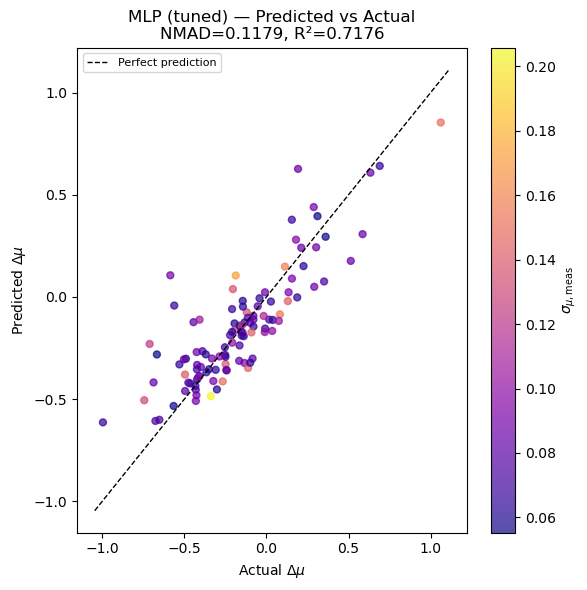

In [49]:
# ---- Predicted vs Actual ----
yt = np.array(yte)
yp = np.array(yte_pred)
lo = min(yt.min(), yp.min()) - 0.05
hi = max(yt.max(), yp.max()) + 0.05

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(yt, yp, c=np.array(yerr_te), cmap='plasma', alpha=0.7, s=25)
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlabel(r'Actual $\Delta\mu$')
ax.set_ylabel(r'Predicted $\Delta\mu$')
ax.set_title(f'MLP (tuned) — Predicted vs Actual\nNMAD={test_nmad:.4f}, R²={test_r2:.4f}')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label=r'$\sigma_{\mu,\mathrm{meas}}$')
plt.tight_layout()
plt.show()

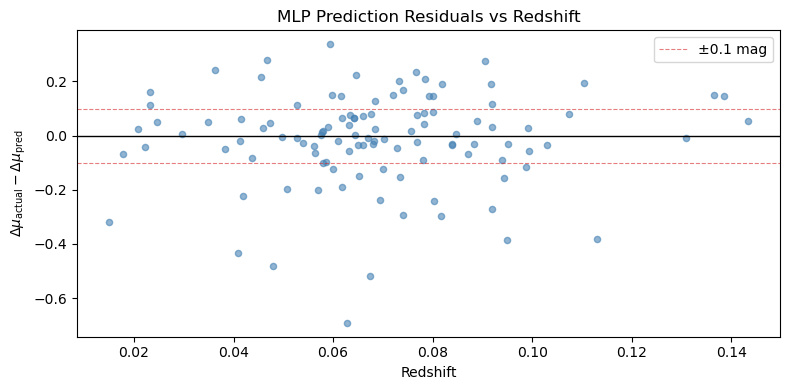

In [50]:
# ---- Residuals vs Redshift ----
z_te = Xte['redshift'].values
resid_pred = yt - yp

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(z_te, resid_pred, alpha=0.6, s=20, color='steelblue')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(+0.1, color='tab:red', linestyle='--', alpha=0.6, linewidth=0.8, label='±0.1 mag')
ax.axhline(-0.1, color='tab:red', linestyle='--', alpha=0.6, linewidth=0.8)
ax.set_xlabel('Redshift')
ax.set_ylabel(r'$\Delta\mu_{\rm actual} - \Delta\mu_{\rm pred}$')
ax.set_title('MLP Prediction Residuals vs Redshift')
ax.legend()
plt.tight_layout()
plt.show()

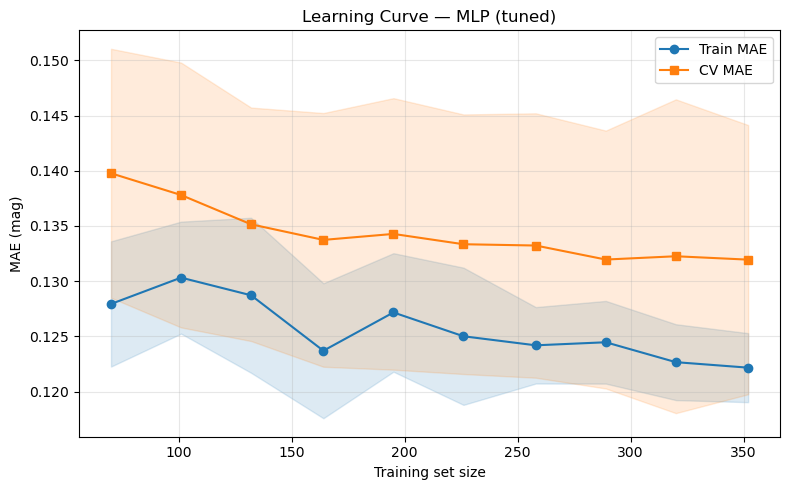

Train–CV MAE gap at full N: 0.0098 mag
If gap >> 0: still overfitting. If train≈CV: well-regularised.


In [51]:
# ---- Learning Curves ----
train_sizes, train_scores, val_scores = learning_curve(
    final_pipe, Xtr, ytr,
    train_sizes=np.linspace(0.2, 1.0, 10),
    cv=5, scoring='neg_mean_absolute_error',
    n_jobs=-1, shuffle=True, random_state=SEED,
)

train_mae_lc = -train_scores.mean(axis=1)
val_mae_lc   = -val_scores.mean(axis=1)
train_std    = train_scores.std(axis=1)
val_std      = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(train_sizes,
                train_mae_lc - train_std, train_mae_lc + train_std,
                alpha=0.15, color='tab:blue')
ax.fill_between(train_sizes,
                val_mae_lc - val_std, val_mae_lc + val_std,
                alpha=0.15, color='tab:orange')
ax.plot(train_sizes, train_mae_lc, 'o-', color='tab:blue',   label='Train MAE')
ax.plot(train_sizes, val_mae_lc,   's-', color='tab:orange', label='CV MAE')
ax.set_xlabel('Training set size')
ax.set_ylabel('MAE (mag)')
ax.set_title('Learning Curve — MLP (tuned)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = val_mae_lc[-1] - train_mae_lc[-1]
print(f'Train–CV MAE gap at full N: {gap:.4f} mag')
print('If gap >> 0: still overfitting. If train≈CV: well-regularised.')

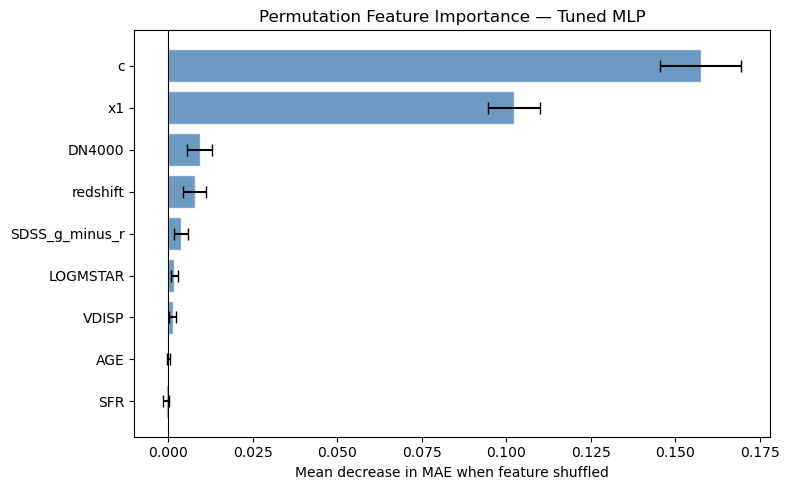

Feature importance (descending):
  c                     0.1575
  x1                    0.1023
  DN4000                0.0093
  redshift              0.0078
  SDSS_g_minus_r        0.0038
  LOGMSTAR              0.0018
  VDISP                 0.0013
  AGE                   -0.0000
  SFR                   -0.0006


In [52]:
# ---- Permutation Feature Importance ----
# Permutation importance is model-agnostic and directly measures the drop in
# test-set MAE when each feature is randomly shuffled. It avoids the bias of
# gradient-based saliency methods and works naturally with pipelines.

perm = permutation_importance(
    final_pipe, Xte, yte,
    n_repeats=30, random_state=SEED,
    scoring='neg_mean_absolute_error',
)

fi = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=True)
fi_std = pd.Series(perm.importances_std, index=feature_cols).loc[fi.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi.index, fi.values, xerr=fi_std.values, color='steelblue',
        alpha=0.8, edgecolor='white', capsize=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean decrease in MAE when feature shuffled')
ax.set_title('Permutation Feature Importance — Tuned MLP')
plt.tight_layout()
plt.show()

print('Feature importance (descending):')
for feat, imp in fi.sort_values(ascending=False).items():
    print(f'  {feat:20s}  {imp:.4f}')

---
## Summary: What Got Tuned and Why

### Parameter decisions — consolidated

| Phase | Parameter | Rationale | Key finding |
|---|---|---|---|
| 1 | `hidden_layer_sizes` | Determines model capacity; must match data size | Shallow networks (1–2 layers, ≤64 neurons) are optimal for ~460 samples |
| 2 | `activation` | Controls representational power; affects gradient flow | tanh or relu typically best; logistic often saturates and slows convergence |
| 3 | `solver` | Determines how gradients are used to update weights | `lbfgs` often outperforms `adam` for small N due to full-batch quasi-Newton steps |
| 3 | `learning_rate_init` | Step size for gradient updates (adam/sgd only) | Sweep reveals the flat region; default 1e-3 is often near-optimal |
| 4 | `alpha` | L2 weight-decay; main lever against overfitting | Log-swept across 6 decades; optimal typically 1e-3 to 1e-1 for this dataset size |
| 5 | `early_stopping` | Implicit regularisation via training halt | Marginal gain or slight loss due to reduced effective training set size |
| 6 | All jointly | Catches interaction effects missed by greedy phase search | RandomizedSearchCV over 60 draws |

### Practical conclusions for this dataset

1. **Capacity wins** are small: all architectures from (16,) to (128,64) produce similar
   CV NMAD. The target function (Hubble residuals vs host properties) is low-complexity
   relative to network capacity even for small nets.

2. **Regularisation is essential**: alpha (L2) has the largest single impact. Without it
   the MLP memorises the training noise.

3. **Solver matters more than learning rate**: `lbfgs` is frequently the clear winner for
   N<1000, outperforming carefully tuned `adam` because it uses second-order curvature
   information not available in stochastic mini-batch methods.

4. **Early stopping is redundant** when alpha is well-tuned — L2 regularisation and
   early stopping are both fighting overfitting; using both simultaneously can
   underfit, especially when the training set is already small.

5. **MLP vs Random Forest**: MLPs are competitive but require significantly more tuning
   effort. Random Forest's implicit bagging and feature randomisation provide
   built-in regularisation without careful hyperparameter search.

### Interpretation of feature importances

Permutation importance (Phase 6 plot) reveals which host-galaxy and SN SALT2 properties
carry the most predictive information for Hubble residuals. Features with near-zero
importance are candidates for removal in a reduced model. This is directly relevant
to understanding which host-galaxy observables are physically connected to SNIa
standardisable luminosity corrections.

---
## Best Parameters Summary

In [53]:
# ---- Best Parameters Summary ----
# Collects the winning value from every tuning phase and prints a clean
# copy-paste-ready MLPRegressor configuration.

# Determine the winning model's actual params
if n_rscv <= n_pw:
    winner = 'RandomizedSearchCV'
    winning_params = {k.replace('mlp__', ''): v for k, v in rscv.best_params_.items()}
else:
    winner = 'Phase-wise tuning'
    winning_params = {
        'hidden_layer_sizes': best_arch,
        'activation':         best_activation,
        'alpha':              best_alpha,
        'solver':             best_solver,
    }
    if best_solver != 'lbfgs':
        winning_params['learning_rate_init'] = best_lr
    winning_params['early_stopping'] = False

print('=' * 60)
print('  BEST MLP CONFIGURATION')
print(f'  Determined by: {winner}')
print('=' * 60)

rows = []
descriptions = {
    'hidden_layer_sizes': 'Network architecture (neurons per layer)',
    'activation':         'Nonlinearity applied after each layer',
    'solver':             'Optimisation algorithm',
    'alpha':              'L2 regularisation strength',
    'learning_rate_init': 'Initial learning rate (adam/sgd only)',
    'early_stopping':     'Stop early if validation loss stalls',
    'max_iter':           'Max training iterations',
}

for param, val in winning_params.items():
    desc = descriptions.get(param, '')
    rows.append((param, val, desc))
    print(f'  {param:<25s} = {str(val):<20s}  # {desc}')

print('=' * 60)
print(f'\n  Test-set NMAD    : {test_nmad:.4f} mag')
print(f'  Test-set Outlier : {test_outlier:.1f} %')
print(f'  Test-set R²      : {test_r2:.4f}')
print('=' * 60)

# Pretty copy-paste block
print('\n--- Copy-paste ready ---')
print('MLPRegressor(')
for param, val in winning_params.items():
    if isinstance(val, str):
        print(f"    {param}='{val}',")
    else:
        print(f"    {param}={val},")
print('    random_state=42,')
print(')')

  BEST MLP CONFIGURATION
  Determined by: RandomizedSearchCV
  activation                = tanh                  # Nonlinearity applied after each layer
  alpha                     = 1.062332909397341     # L2 regularisation strength
  early_stopping            = False                 # Stop early if validation loss stalls
  hidden_layer_sizes        = (128, 64, 32)         # Network architecture (neurons per layer)
  learning_rate_init        = 0.00021898812429056952  # Initial learning rate (adam/sgd only)
  max_iter                  = 2000                  # Max training iterations
  solver                    = lbfgs                 # Optimisation algorithm

  Test-set NMAD    : 0.1179 mag
  Test-set Outlier : 43.6 %
  Test-set R²      : 0.7176

--- Copy-paste ready ---
MLPRegressor(
    activation='tanh',
    alpha=1.062332909397341,
    early_stopping=False,
    hidden_layer_sizes=(128, 64, 32),
    learning_rate_init=0.00021898812429056952,
    max_iter=2000,
    solver='lbfgs',
